# 4 · Buckling

Euler columns, inelastic column curves, plate buckling, and FEA eigenvalue buckling. Theory:
[docs/buckling.md](../docs/buckling.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from structures import plotting as P

P.use_style()
DEG = np.pi / 180
MPA = 1e6
from structures.buckling import (EFFECTIVE_LENGTH, euler_load, column_model, linear_buckling,
                                 johnson_stress, tangent_modulus_stress, compression_k,
                                 plate_critical_stress)
from structures.materials import isotropic, KSI

In [2]:
E, A, I, L = 70e9, 3e-4, 1e-8, 1.2
for end, K in EFFECTIVE_LENGTH.items():
    P_e = euler_load(E, I, L, end)
    P_fe = linear_buckling(column_model(L, 8, E, A, I, end)).load_factors[0]
    print(f"{end:14s} K = {K:.4f}  Euler {P_e:9.2f} N   FEA(8 el.) {P_fe:9.2f} N   error {P_fe/P_e - 1:.1e}")

pinned-pinned  K = 1.0000  Euler   4797.72 N   FEA(8 el.)   4797.88 N   error 3.3e-05
fixed-free     K = 2.0000  Euler   1199.43 N   FEA(8 el.)   1199.43 N   error 2.1e-06
fixed-fixed    K = 0.5000  Euler  19190.90 N   FEA(8 el.)  19200.73 N   error 5.1e-04
fixed-pinned   K = 0.6992  Euler   9814.94 N   FEA(8 el.)   9816.27 N   error 1.4e-04


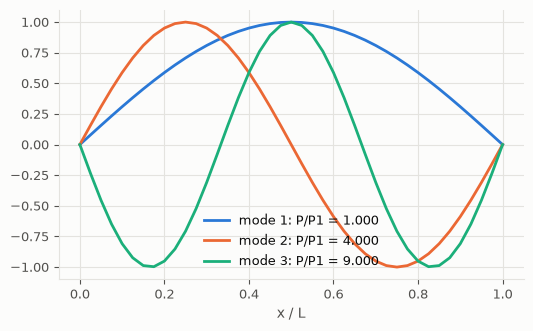

In [3]:
res = linear_buckling(column_model(L, 40, E, A, I, "pinned-pinned"), n_modes=3)
x = np.linspace(0, 1, 41)
fig, ax = plt.subplots(figsize=(6, 3.5))
for j in range(3):
    ax.plot(x, res.modes[1::3, j], label=f"mode {j+1}: P/P1 = {res.load_factors[j]/res.load_factors[0]:.3f}")
ax.set_xlabel("x / L"); ax.legend();

In [4]:
m = isotropic("2024-T3")
lam = np.array([10, 30, 50, 70, 90, 120])
print("L'/rho  Johnson[ksi]  tangent-modulus(n=15)[ksi]")
for l, j, t in zip(lam, johnson_stress(m.Ec, m.Fcy, lam), tangent_modulus_stress(m.Ec, m.Fcy, 15, lam)):
    print(f"{l:6.0f}  {j/KSI:12.1f}  {min(t, m.Fcy)/KSI:12.1f}")

L'/rho  Johnson[ksi]  tangent-modulus(n=15)[ksi]
    10          39.6          40.0
    30          36.6          36.5
    50          30.5          31.8
    70          21.4          21.5
    90          13.0          13.0
   120           7.3           7.3


In [5]:
# A 2024-T3 skin bay between stringers: 150 mm wide, 450 mm long, 1.6 mm thick
k, half_waves = compression_k(450 / 150)
s_cr = plate_critical_stress(m.Ec, m.nu, 1.6e-3, 0.150, k)
print(f"k = {k:.3f} with {half_waves} half-waves; sigma_cr = {s_cr/MPA:.1f} MPa "
      f"({s_cr/m.Fcy:.0%} of Fcy): thin skins buckle long before they yield")

k = 4.000 with 3 half-waves; sigma_cr = 31.0 MPa (11% of Fcy): thin skins buckle long before they yield
